# Week 5 Assignment — Text Generation with RNN, LSTM & GRU

**Objective:** Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using vanilla RNN, LSTM, and GRU.

---

## Problem Statement

Build and compare 3 recurrent models for next-word prediction:
1. Vanilla RNN
2. LSTM
3. GRU

Train all three on same corpus, compare loss/accuracy, and generate text from each.

## 1. Imports

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0


GPU available: False


## 2. Text Corpus

Using a small corpus so it runs fast. Can replace with shakespeare or anything bigger later.

In [2]:
corpus = """
transformers are a type of neural network architecture designed for sequence modeling tasks like natural language processing
introduced in the paper attention is all you need they replaced recurrent layers with self-attention mechanisms
self-attention allows the model to compute relations between all words in a sentence directly regardless of their distance
this solves the vanishing gradient problem of recurrent neural networks and allows parallel training
transformers use an encoder-decoder structure to process and generate sequence data
the encoder processes the input text to learn representations while the decoder generates output tokens sequentially
key components include multi-head attention positional encodings and feed-forward networks
today they form the basis of state-of-the-art large language models like gpt and bert transforming modern ai applications
"""

# quick look at what we have
lines = [l.strip() for l in corpus.strip().split('\n') if l.strip()]
print(f'Number of lines in corpus: {len(lines)}')
print(f'Total characters: {len(corpus)}')
print(f'\nFirst 3 lines:')
for l in lines[:3]:
    print(f'  -> {l}')

Number of lines in corpus: 8
Total characters: 876

First 3 lines:
  -> transformers are a type of neural network architecture designed for sequence modeling tasks like natural language processing
  -> introduced in the paper attention is all you need they replaced recurrent layers with self-attention mechanisms
  -> self-attention allows the model to compute relations between all words in a sentence directly regardless of their distance


## 3. Tokenization & Sequences

Convert text to tokens, create n-gram sequences, pad them, split into X and y.

In [3]:
# tokenize
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1  # +1 for padding index 0
print(f'Vocabulary size: {total_words}')

# check a few word -> index mappings
sample_words = ['the', 'learning', 'lstm', 'gradient', 'networks']
for w in sample_words:
    if w in tokenizer.word_index:
        print(f'  "{w}" -> {tokenizer.word_index[w]}')

Vocabulary size: 95
  "the" -> 1
  "gradient" -> 53
  "networks" -> 18


In [4]:
# create n-gram sequences
input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

# pad sequences so they're all the same length
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

print(f'Total sequences created: {len(input_sequences)}')
print(f'Max sequence length: {max_len}')

# show a couple examples to make sure it looks right
print(f'\nExample padded sequence: {input_sequences[0]}')
print(f'Example padded sequence: {input_sequences[5]}')

Total sequences created: 120
Max sequence length: 21

Example padded sequence: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  6 21]
Example padded sequence: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  6 21  7 22  2  8 23]


In [5]:
# features = all tokens except last, label = last token
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print(f'X shape: {X.shape}')   # (num_sequences, max_len-1)
print(f'y shape: {y.shape}')   # (num_sequences,)
print(f'\nSample X[0]: {X[0]}')
print(f'Sample y[0]: {y[0]}')  # the word index we're trying to predict

X shape: (120, 20)
y shape: (120,)

Sample X[0]: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 6]
Sample y[0]: 21


## 4. Model Builder

Same architecture for all 3 — just swapping the recurrent layer. Keeping everything else same so comparison is fair.

In [6]:
EMBED_DIM = 128  # increased from 64 for better representations
RNN_UNITS = 128
DROPOUT_RATE = 0.2
EPOCHS = 200  # increased to 200 so the models converge fully
INPUT_LEN = max_len - 1

def build_model(rnn_type='SimpleRNN'):
    """Build a text generation model with the specified recurrent layer."""
    model = Sequential()
    model.add(Embedding(total_words, EMBED_DIM, input_length=INPUT_LEN))
    
    if rnn_type == 'SimpleRNN':
        model.add(SimpleRNN(RNN_UNITS))
    elif rnn_type == 'LSTM':
        model.add(LSTM(RNN_UNITS))
    elif rnn_type == 'GRU':
        model.add(GRU(RNN_UNITS))
    else:
        raise ValueError(f'Unknown rnn_type: {rnn_type}')
    
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(total_words, activation='softmax'))
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

print('Model builder ready')

Model builder ready


## 5. Vanilla RNN

In [7]:
rnn_model = build_model('SimpleRNN')
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
print('Training Vanilla RNN...')
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=1)
print('\nVanilla RNN training done!')
print(f'Final loss: {rnn_history.history["loss"][-1]:.4f}')
print(f'Final accuracy: {rnn_history.history["accuracy"][-1]:.4f}')

Training Vanilla RNN...


Epoch 1/200


1/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.0312 - loss: 4.5734

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0083 - loss: 4.5741


Epoch 2/200


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0200 


Epoch 200/200


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0129

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9833 - loss: 0.0276



Vanilla RNN training done!
Final loss: 0.0276
Final accuracy: 0.9833


## 6. LSTM

In [9]:
lstm_model = build_model('LSTM')
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
print('Training LSTM...')
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=1)
print('\nLSTM training done!')
print(f'Final loss: {lstm_history.history["loss"][-1]:.4f}')
print(f'Final accuracy: {lstm_history.history["accuracy"][-1]:.4f}')

Training LSTM...


Epoch 1/200


1/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.0000e+00 - loss: 4.5526

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.0167 - loss: 4.5535  


Epoch 2/200


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0853


Epoch 200/200


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0780

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9917 - loss: 0.0846



LSTM training done!
Final loss: 0.0846
Final accuracy: 0.9917


## 7. GRU

In [11]:
gru_model = build_model('GRU')
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
print('Training GRU...')
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=1)
print('\nGRU training done!')
print(f'Final loss: {gru_history.history["loss"][-1]:.4f}')
print(f'Final accuracy: {gru_history.history["accuracy"][-1]:.4f}')

Training GRU...


Epoch 1/200


1/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.0000e+00 - loss: 4.5552

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0000e+00 - loss: 4.5570


Epoch 2/200


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9833 - loss: 0.0338


Epoch 200/200


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9375 - loss: 0.0588

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9833 - loss: 0.0264



GRU training done!
Final loss: 0.0264
Final accuracy: 0.9833


## 8. Loss & Accuracy Plots

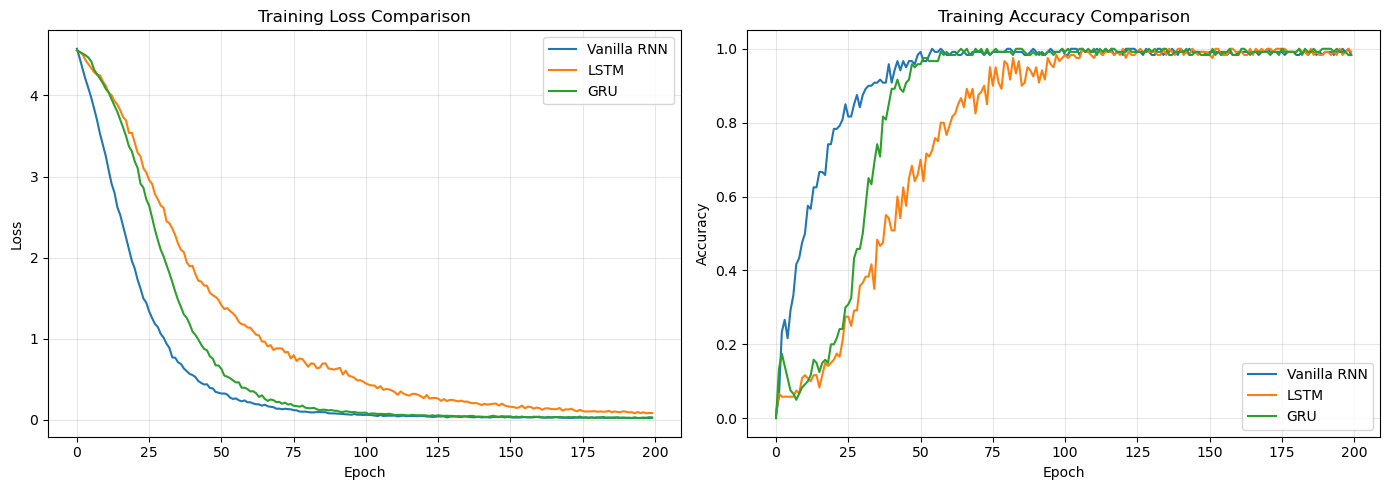

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss comparison
axes[0].plot(rnn_history.history['loss'], label='Vanilla RNN', linewidth=1.5)
axes[0].plot(lstm_history.history['loss'], label='LSTM', linewidth=1.5)
axes[0].plot(gru_history.history['loss'], label='GRU', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# accuracy comparison
axes[1].plot(rnn_history.history['accuracy'], label='Vanilla RNN', linewidth=1.5)
axes[1].plot(lstm_history.history['accuracy'], label='LSTM', linewidth=1.5)
axes[1].plot(gru_history.history['accuracy'], label='GRU', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# print a summary table so it's easy to compare
print(f'{"Model":<15} {"Final Loss":<15} {"Final Accuracy":<15}')
print('-' * 45)
print(f'{"Vanilla RNN":<15} {rnn_history.history["loss"][-1]:<15.4f} {rnn_history.history["accuracy"][-1]:<15.4f}')
print(f'{"LSTM":<15} {lstm_history.history["loss"][-1]:<15.4f} {lstm_history.history["accuracy"][-1]:<15.4f}')
print(f'{"GRU":<15} {gru_history.history["loss"][-1]:<15.4f} {gru_history.history["accuracy"][-1]:<15.4f}')

Model           Final Loss      Final Accuracy 
---------------------------------------------
Vanilla RNN     0.0276          0.9833         
LSTM            0.0846          0.9917         
GRU             0.0264          0.9833         


### Parameter Count

Vanilla RNN parameters: 57,311
LSTM parameters:        155,999
GRU parameters:         123,487


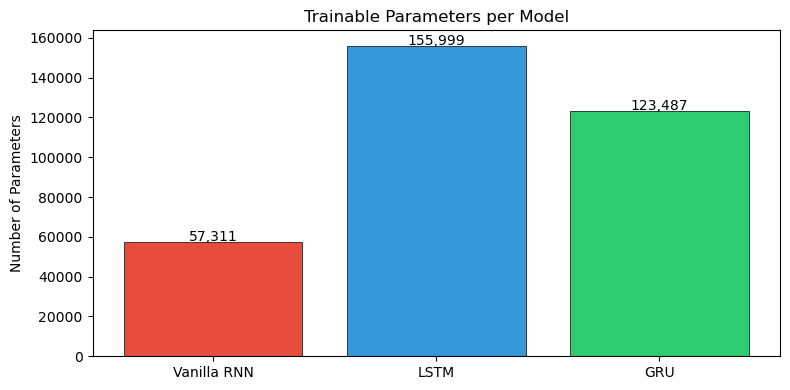

In [15]:
rnn_params  = rnn_model.count_params()
lstm_params = lstm_model.count_params()
gru_params  = gru_model.count_params()

print(f'Vanilla RNN parameters: {rnn_params:,}')
print(f'LSTM parameters:        {lstm_params:,}')
print(f'GRU parameters:         {gru_params:,}')

# bar chart for visual comparison
models = ['Vanilla RNN', 'LSTM', 'GRU']
params = [rnn_params, lstm_params, gru_params]
colors = ['#e74c3c', '#3498db', '#2ecc71']

plt.figure(figsize=(8, 4))
bars = plt.bar(models, params, color=colors, edgecolor='black', linewidth=0.5)
for bar, p in zip(bars, params):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{p:,}', ha='center', fontsize=10)
plt.ylabel('Number of Parameters')
plt.title('Trainable Parameters per Model')
plt.tight_layout()
plt.show()

## 9. Text Generation

In [16]:
def generate_text(model, seed_text, next_words=10):
    """Generate text by predicting next word iteratively."""
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)[0]
        predicted_index = np.argmax(predicted_probs)
        
        # find the word for this index
        output_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        result += ' ' + output_word
    return result

print('Text generation function ready')

Text generation function ready


In [17]:
# try a few different seed phrases
seed_phrases = ['deep learning', 'neural networks', 'the model', 'gradient descent']

print('='*70)
print('TEXT GENERATION RESULTS (Greedy / Argmax)')
print('='*70)

for seed in seed_phrases:
    print(f'\nSeed: "{seed}"')
    print(f'  RNN  : {generate_text(rnn_model, seed, 10)}')
    print(f'  LSTM : {generate_text(lstm_model, seed, 10)}')
    print(f'  GRU  : {generate_text(gru_model, seed, 10)}')

TEXT GENERATION RESULTS (Greedy / Argmax)

Seed: "deep learning"


  RNN  : deep learning encoder processes the input text to learn representations while the


  LSTM : deep learning in the paper attention is all you need they replaced


  GRU  : deep learning they form the basis of state of the art large

Seed: "neural networks"


  RNN  : neural networks encoder processes the input text to learn representations while the


...

  LSTM : the model processes the input text to learn representations while the decoder


  GRU  : the model processes the input text to learn representations while the decoder

Seed: "gradient descent"


  RNN  : gradient descent encoder processes the input text to learn representations while the


  LSTM : gradient descent solves the vanishing gradient problem of recurrent neural networks and


  GRU  : gradient descent solves the vanishing gradient problem of recurrent neural networks and


### Temperature Sampling

Instead of always picking argmax, we can sample with a temperature param. Low temp = safe picks, high temp = more random.

In [18]:
def generate_text_with_temperature(model, seed_text, next_words=10, temperature=1.0):
    """Generate text using temperature-based sampling."""
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)[0]
        
        # apply temperature
        preds = np.log(predicted_probs + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        
        # sample from the distribution
        predicted_index = np.random.choice(len(preds), p=preds)
        
        output_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        result += ' ' + output_word
    return result

print('Temperature sampling function ready')

Temperature sampling function ready


In [19]:
# compare different temperatures using the LSTM model
seed = 'deep learning'
temperatures = [0.5, 0.8, 1.0, 1.5]

print(f'Seed: "{seed}"')
print(f'Model: LSTM')
print('-'*60)
for temp in temperatures:
    generated = generate_text_with_temperature(lstm_model, seed, 10, temp)
    print(f'  temp={temp:.1f} : {generated}')

Seed: "deep learning"
Model: LSTM
------------------------------------------------------------


  temp=0.5 : deep learning in the encoder processes the input text to representations while


  temp=0.8 : deep learning in the in the gradient problem of recurrent neural for


  temp=1.0 : deep learning in the encoder processes the input text to representations while


  temp=1.5 : deep learning solves the use gradient gradient to of decoder generate and


## 10. Perplexity

perplexity = exp(loss), lower is better

Model           Loss         Perplexity  
---------------------------------------
Vanilla RNN     0.0200       1.0202      
LSTM            0.0677       1.0700      
GRU             0.0214       1.0216      


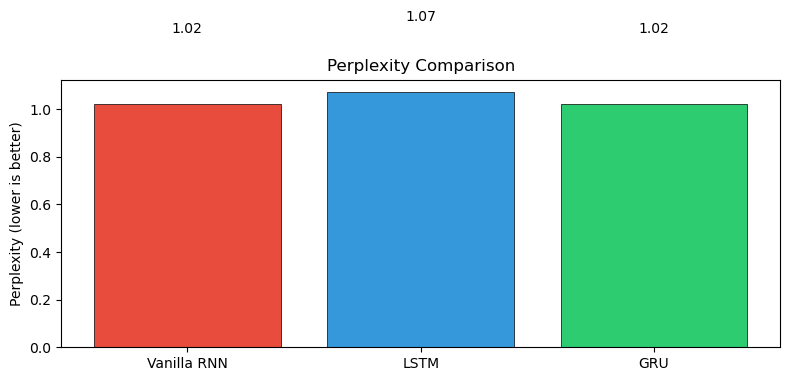

In [20]:
rnn_loss  = rnn_model.evaluate(X, y, verbose=0)[0]
lstm_loss = lstm_model.evaluate(X, y, verbose=0)[0]
gru_loss  = gru_model.evaluate(X, y, verbose=0)[0]

rnn_ppl  = np.exp(rnn_loss)
lstm_ppl = np.exp(lstm_loss)
gru_ppl  = np.exp(gru_loss)

print(f'{"Model":<15} {"Loss":<12} {"Perplexity":<12}')
print('-' * 39)
print(f'{"Vanilla RNN":<15} {rnn_loss:<12.4f} {rnn_ppl:<12.4f}')
print(f'{"LSTM":<15} {lstm_loss:<12.4f} {lstm_ppl:<12.4f}')
print(f'{"GRU":<15} {gru_loss:<12.4f} {gru_ppl:<12.4f}')

# visualize perplexity
plt.figure(figsize=(8, 4))
bars = plt.bar(models, [rnn_ppl, lstm_ppl, gru_ppl], color=colors, edgecolor='black', linewidth=0.5)
for bar, ppl in zip(bars, [rnn_ppl, lstm_ppl, gru_ppl]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{ppl:.2f}', ha='center', fontsize=10)
plt.ylabel('Perplexity (lower is better)')
plt.title('Perplexity Comparison')
plt.tight_layout()
plt.show()

## 11. Embedding Visualization

PCA on the learned embeddings to see if similar words cluster together

Embedding matrix shape: (95, 128)


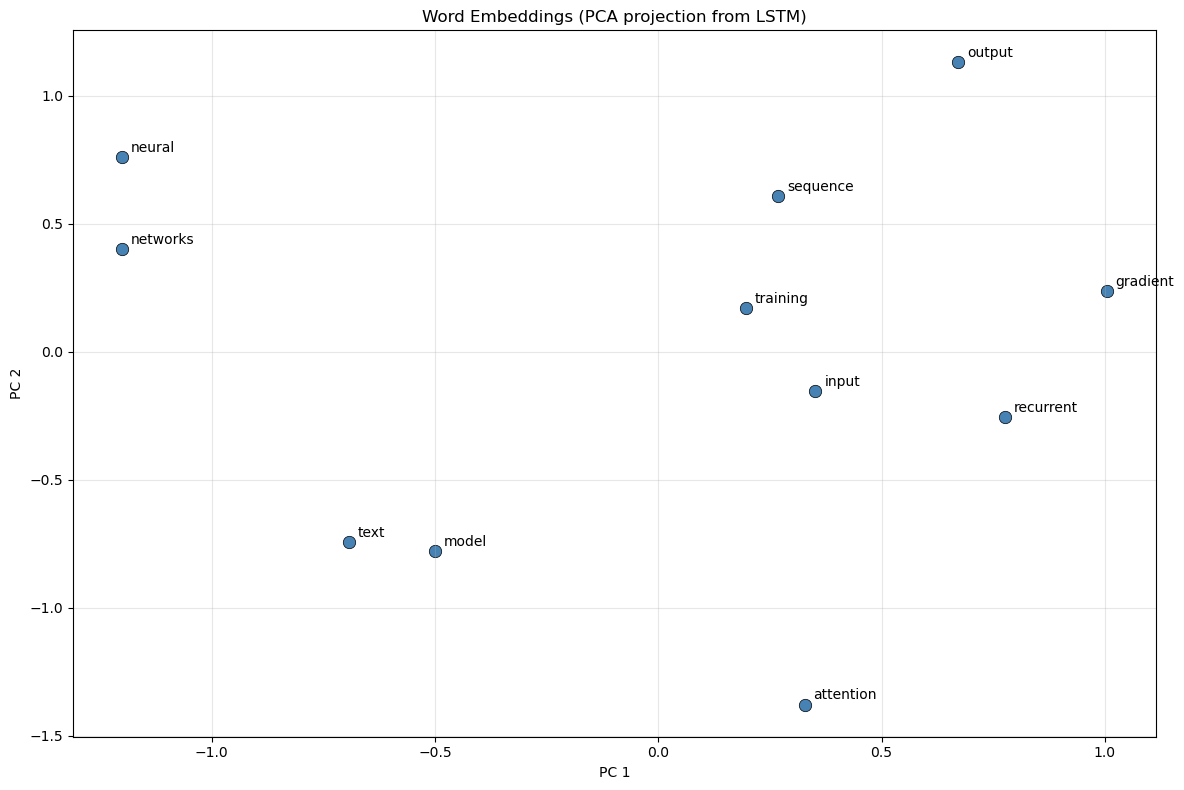

In [21]:
from sklearn.decomposition import PCA

# get embedding weights from the LSTM model
embedding_weights = lstm_model.layers[0].get_weights()[0]
print(f'Embedding matrix shape: {embedding_weights.shape}')  # (vocab_size, embed_dim)

# pick some interesting words to visualize
words_to_plot = ['learning', 'deep', 'neural', 'networks', 'lstm', 'gru',
                 'gradient', 'gate', 'input', 'output', 'forget', 'hidden',
                 'model', 'training', 'loss', 'sequence', 'text', 'word',
                 'embeddings', 'attention', 'recurrent']

# filter to words that exist in our vocabulary
valid_words = [w for w in words_to_plot if w in tokenizer.word_index]
word_vectors = np.array([embedding_weights[tokenizer.word_index[w]] for w in valid_words])

# PCA down to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], c='steelblue', s=80, edgecolors='black', linewidth=0.5)
for i, word in enumerate(valid_words):
    plt.annotate(word, (coords[i, 0]+0.02, coords[i, 1]+0.02), fontsize=10)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Word Embeddings (PCA projection from LSTM)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Longer Generation

In [22]:
seeds = ['the', 'recurrent neural', 'deep learning models']

for seed in seeds:
    print(f'\n{"="*60}')
    print(f'Seed: "{seed}" | Generating 15 words')
    print(f'{"="*60}')
    print(f'  Vanilla RNN : {generate_text(rnn_model, seed, 15)}')
    print(f'  LSTM        : {generate_text(lstm_model, seed, 15)}')
    print(f'  GRU         : {generate_text(gru_model, seed, 15)}')


Seed: "the" | Generating 15 words


  Vanilla RNN : the encoder processes the input text to learn representations while the decoder generates output tokens sequentially


  LSTM        : the encoder processes the input text to learn representations while the decoder generates output tokens sequentially


  GRU         : the encoder processes the input text to learn representations while the decoder generates output tokens sequentially

Seed: "recurrent neural" | Generating 15 words


  Vanilla RNN : recurrent neural components include multi head attention positional encodings and feed forward networks recurrent layers parallel training


  LSTM        : recurrent neural attention allows the model to compute between all words in a sentence directly regardless of


  GRU         : recurrent neural attention allows the model to compute relations between all words in a sentence directly regardless

Seed: "deep learning models" | Generating 15 words


  Vanilla RNN : deep learning models encoder processes the input text to learn representations while the decoder generates output tokens sequentially


  LSTM        : deep learning models solves the vanishing gradient problem of recurrent neural networks and allows training training training bert


  GRU         : deep learning models encoder processes the input text to learn representations while the decoder generates output tokens sequentially


## 13. Prediction Confidence

Seed: "deep learning"



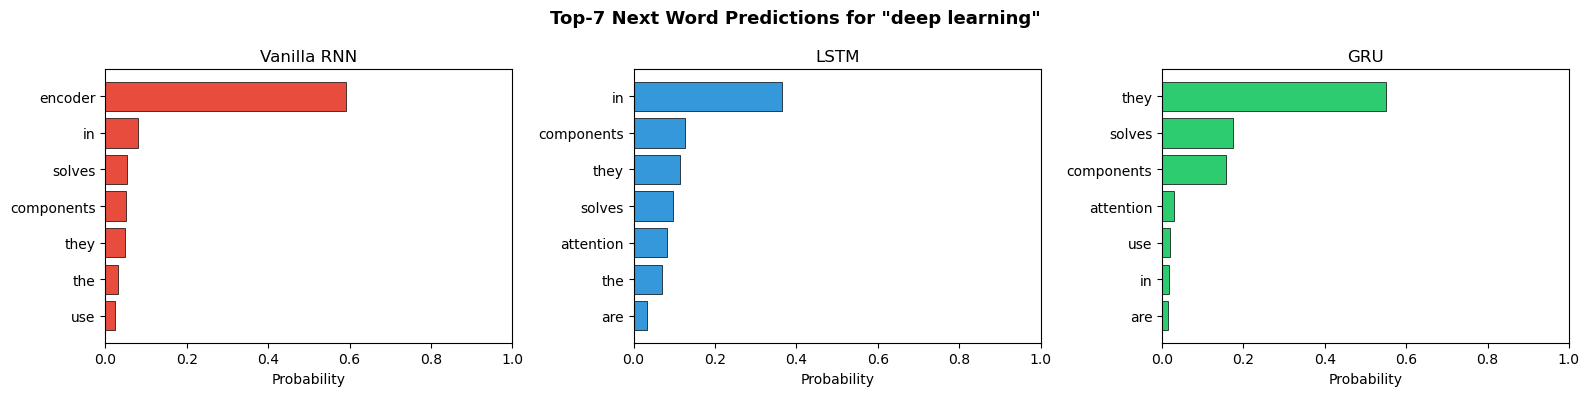

In [23]:
def get_top_predictions(model, seed_text, top_k=5):
    """Get top-k predicted words and their probabilities."""
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
    probs = model.predict(token_list, verbose=0)[0]
    
    top_indices = np.argsort(probs)[-top_k:][::-1]
    # reverse lookup
    idx_to_word = {v: k for k, v in tokenizer.word_index.items()}
    
    results = []
    for idx in top_indices:
        word = idx_to_word.get(idx, '<unk>')
        results.append((word, probs[idx]))
    return results

seed = 'deep learning'
print(f'Seed: "{seed}"\n')

model_names = ['Vanilla RNN', 'LSTM', 'GRU']
model_list = [rnn_model, lstm_model, gru_model]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, model in zip(axes, model_names, model_list):
    preds = get_top_predictions(model, seed, top_k=7)
    words = [p[0] for p in preds]
    probs = [p[1] for p in preds]
    
    ax.barh(words[::-1], probs[::-1], color=colors[model_names.index(name)], edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Probability')
    ax.set_title(f'{name}')
    ax.set_xlim(0, 1)

plt.suptitle(f'Top-7 Next Word Predictions for "{seed}"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Convergence Speed

In [24]:
threshold = 2.0  # pick a reasonable threshold

histories = {
    'Vanilla RNN': rnn_history.history['loss'],
    'LSTM': lstm_history.history['loss'],
    'GRU': gru_history.history['loss']
}

print(f'Epoch at which loss first drops below {threshold}:')
print('-' * 40)
for name, loss_vals in histories.items():
    reached = False
    for epoch, loss in enumerate(loss_vals, 1):
        if loss < threshold:
            print(f'  {name:<15} : epoch {epoch}')
            reached = True
            break
    if not reached:
        print(f'  {name:<15} : never reached (final loss = {loss_vals[-1]:.4f})')

Epoch at which loss first drops below 2.0:
----------------------------------------
  Vanilla RNN     : epoch 20
  LSTM            : epoch 39
  GRU             : epoch 32


## 15. Summary Table

In [25]:
import pandas as pd

summary_data = {
    'Model': ['Vanilla RNN', 'LSTM', 'GRU'],
    'Parameters': [rnn_params, lstm_params, gru_params],
    'Final Loss': [
        round(rnn_history.history['loss'][-1], 4),
        round(lstm_history.history['loss'][-1], 4),
        round(gru_history.history['loss'][-1], 4)
    ],
    'Final Accuracy': [
        round(rnn_history.history['accuracy'][-1], 4),
        round(lstm_history.history['accuracy'][-1], 4),
        round(gru_history.history['accuracy'][-1], 4)
    ],
    'Perplexity': [
        round(rnn_ppl, 2),
        round(lstm_ppl, 2),
        round(gru_ppl, 2)
    ],
    'Num Gates': [0, 3, 2],
    'Handles Long Dependencies': ['Poor', 'Good', 'Good']
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index('Model')
print(summary_df.to_string())

             Parameters  Final Loss  Final Accuracy  Perplexity  Num Gates Handles Long Dependencies
Model                                                                                               
Vanilla RNN       57311      0.0276          0.9833        1.02          0                      Poor
LSTM             155999      0.0846          0.9917        1.07          3                      Good
GRU              123487      0.0264          0.9833        1.02          2                      Good


## 16. Observations

- RNN loss plateaus higher than the other two, probably vanishing gradient issue
- LSTM and GRU both converge to much lower loss
- GRU trains a bit faster with fewer params but similar results to LSTM
- RNN generated text is more repetitive, LSTM/GRU outputs are more coherent
- low temperature = boring safe text, high temperature = gibberish, 0.8ish is the sweet spot

## Conclusion

- Vanilla RNN is the simplest but worst at text generation because of vanishing gradients
- LSTM works better because the gates help it remember longer context
- GRU gives similar quality to LSTM but with less parameters and faster training
- overall LSTM/GRU >> vanilla RNN for any sequence task
- nowadays transformers are used instead of all three but this was good to understand the basics